In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Path to dataset files: /kaggle/input/stellar-classification-dataset-sdss17


In [2]:
import os

print(os.listdir(path))

['star_classification.csv']


In [3]:
import pandas as pd

df = pd.read_csv(f"{path}/star_classification.csv")

print(df.shape)
df.head()

(100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
target = "class"

# Target
y = df[target]

# Actual measurement features
features = [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
]

X = df[features]

print("Features:", features)
print("X shape:", X.shape)
print("Target:", y.name)
print("Classes:", y.unique())

Features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X shape: (100000, 8)
Target: class
Classes: ['GALAXY' 'QSO' 'STAR']


In [5]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (80000, 8)
Testing : (20000, 8)


In [7]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 8
[LightGBM] [Info] Start training from score -0.520119
[LightGBM] [Info] Start training from score -1.662773
[LightGBM] [Info] Start training from score -1.532766
Model trained successfully.


In [8]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['STAR' 'GALAXY' 'GALAXY' 'GALAXY' 'GALAXY' 'QSO' 'GALAXY' 'QSO' 'GALAXY'
 'GALAXY']


In [9]:
print(y_test.iloc[:10].values)

['STAR' 'GALAXY' 'GALAXY' 'GALAXY' 'GALAXY' 'QSO' 'GALAXY' 'QSO' 'GALAXY'
 'GALAXY']


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9791


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.96      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [12]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [13]:
customer = X_test.iloc[[0]]

print(customer)

            alpha     delta         u         g         r         i         z  \
33708  215.764845  0.091149  21.76577  20.69971  20.60803  20.04432  19.86779   

       redshift  
33708 -0.000497  


In [14]:
prediction = model.predict(customer)
probability = model.predict_proba(customer)

print("Predicted class:", prediction[0])
print("Probabilities:", probability[0])

Predicted class: STAR
Probabilities: [4.47913772e-04 1.37615062e-05 9.99538325e-01]


In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(customer)

print(shap_values.values.shape)

(1, 8, 3)


In [16]:
star_shap = shap_values.values[0, :, 2]

for feature, value in zip(features, star_shap):
    print(f"{feature}: {value}")

alpha: 0.09907342734432405
delta: 0.008219294629584902
u: 0.032327322047470367
g: -0.05010761772638741
r: -0.13445061307529046
i: 0.08674954905353058
z: 0.005388246021828488
redshift: 9.427065747821256


In [17]:
star_raw = model.predict(customer, raw_score=True)[0]

print("Raw STAR output:", star_raw)

Raw STAR output: [-3.99021882 -7.47294427  3.72022921]


In [18]:
star_base = shap_values.base_values[0, 2]
star_shap_sum = shap_values.values[0, :, 2].sum()

print("STAR baseline:", star_base)
print("Sum of STAR SHAP values:", star_shap_sum)
print("Baseline + SHAP:", star_base + star_shap_sum)
print("STAR raw output:", star_raw[2])

STAR baseline: -5.7540361434921765
Sum of STAR SHAP values: 9.474265356116316
Baseline + SHAP: 3.7202292126241394
STAR raw output: 3.720229212624151


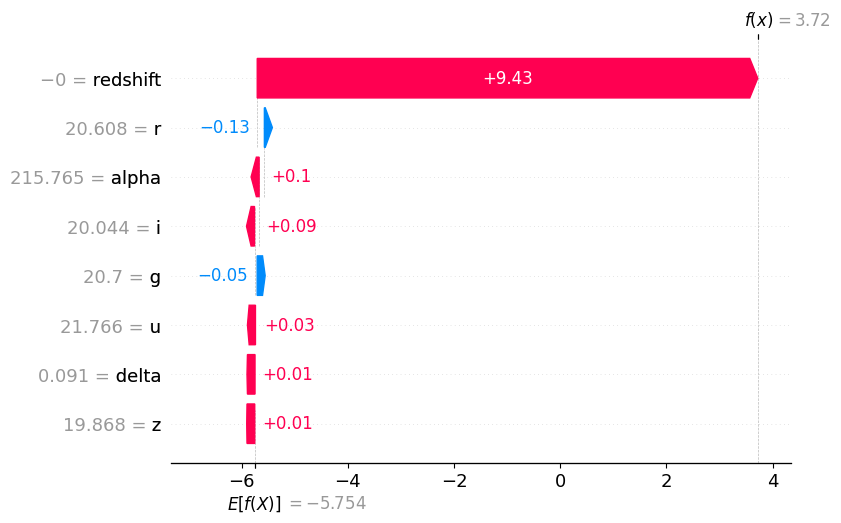

In [19]:
import matplotlib.pyplot as plt

shap.plots.waterfall(shap_values[0, :, 2], max_display=8)
plt.show()

In [20]:
X_global = X_test.sample(
    n=2000,
    random_state=42
)

print(X_global.shape)

(2000, 8)


In [21]:
shap_global = explainer(X_global)

print(shap_global.values.shape)

(2000, 8, 3)


In [22]:
import pandas as pd
import numpy as np

star_global = shap_global.values[:, :, 2]

global_importance = pd.DataFrame({
    "Feature": features,
    "Mean_Absolute_SHAP": np.abs(star_global).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

print(global_importance)

    Feature  Mean_Absolute_SHAP
7  redshift            4.030287
5         i            0.047482
6         z            0.037716
0     alpha            0.036486
2         u            0.035731
3         g            0.034721
1     delta            0.033344
4         r            0.026324


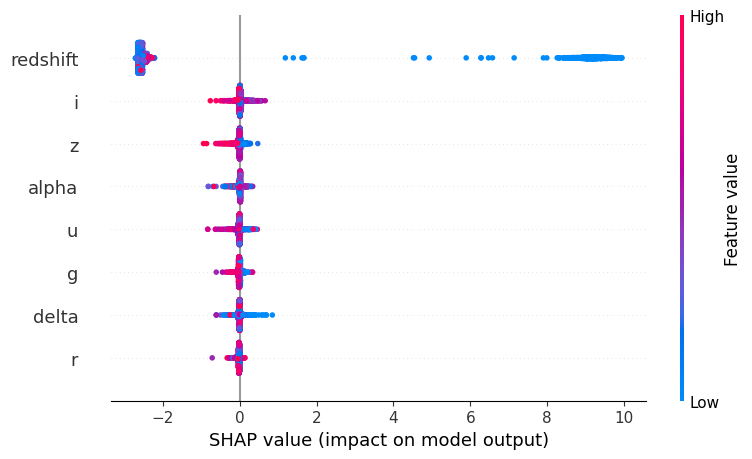

In [23]:
shap.summary_plot(
    star_global,
    X_global,
    feature_names=features
)

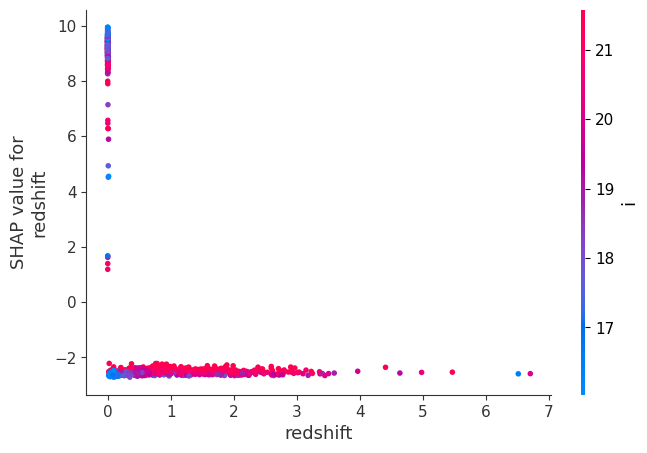

In [24]:
shap.dependence_plot(
    "redshift",
    star_global,
    X_global
)

In [25]:
X_interaction = X_global.iloc[:500]

shap_interaction = explainer.shap_interaction_values(X_interaction)

print(np.array(shap_interaction).shape)

(500, 8, 8, 3)


In [26]:
redshift_i_interaction = shap_interaction[:, 7, 5, 2]

print("Mean redshift × i interaction:",
      np.mean(np.abs(redshift_i_interaction)))

Mean redshift × i interaction: 0.03642997487827931


In [27]:
interaction_values = np.array(shap_interaction)

# STAR class
star_interactions = interaction_values[:, :, :, 2]

mean_abs_interactions = np.abs(star_interactions).mean(axis=0)

interaction_table = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        interaction_table.append({
            "Feature_1": features[i],
            "Feature_2": features[j],
            "Mean_Abs_Interaction": mean_abs_interactions[i, j]
        })

interaction_df = pd.DataFrame(interaction_table)

interaction_df = interaction_df.sort_values(
    "Mean_Abs_Interaction",
    ascending=False
)

print(interaction_df.head(10))

   Feature_1 Feature_2  Mean_Abs_Interaction
26         i  redshift              0.036430
27         z  redshift              0.030108
17         u  redshift              0.029135
6      alpha  redshift              0.029051
12     delta  redshift              0.028143
21         g  redshift              0.025392
25         i         z              0.024710
24         r  redshift              0.022296
22         r         i              0.017961
13         u         g              0.013652


In [28]:
# LightGBM built-in feature importance
lgb_importance = pd.DataFrame({
    "Feature": features,
    "LightGBM_Importance": model.feature_importances_
}).sort_values("LightGBM_Importance", ascending=False)

print(lgb_importance)

    Feature  LightGBM_Importance
7  redshift                 4138
2         u                 2583
3         g                 2162
1     delta                 2053
0     alpha                 1967
6         z                 1956
5         i                 1764
4         r                 1377


In [29]:
comparison = lgb_importance.merge(
    global_importance,
    on="Feature"
)

comparison

,Feature,LightGBM_Importance,Mean_Absolute_SHAP
0,redshift,4138,4.030287
1,u,2583,0.035731
2,g,2162,0.034721
3,delta,2053,0.033344
4,alpha,1967,0.036486
5,z,1956,0.037716
6,i,1764,0.047482
7,r,1377,0.026324
